# RQ2: Which features (e.g., Ad_Spend, Clicks, Category, Region) are the most important predictors of sales revenue?
**Dataset:** Marketing and Product Performance Dataset (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available.')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not available; using built-in feature importance.')

SHAP available.


In [2]:
# ── LOAD & PREPROCESS ─────────────────────────────────────────────────────────
df = pd.read_csv('marketing_and_product_performance.csv')
df = df.copy()
drop_cols = [c for c in df.columns if 'id' in c.lower() or 'name' in c.lower()]
df.drop(columns=drop_cols, errors='ignore', inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

target = 'Revenue_Generated'
X = df.drop(columns=[target])
y = df[target]
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print('Preprocessing done. Features:', feature_names)

Preprocessing done. Features: ['Budget', 'Clicks', 'Conversions', 'ROI', 'Subscription_Tier', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund', 'Common_Keywords']


In [3]:
# ── TRAIN RANDOM FOREST & GRADIENT BOOSTING ───────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
print('Models trained.')

Models trained.


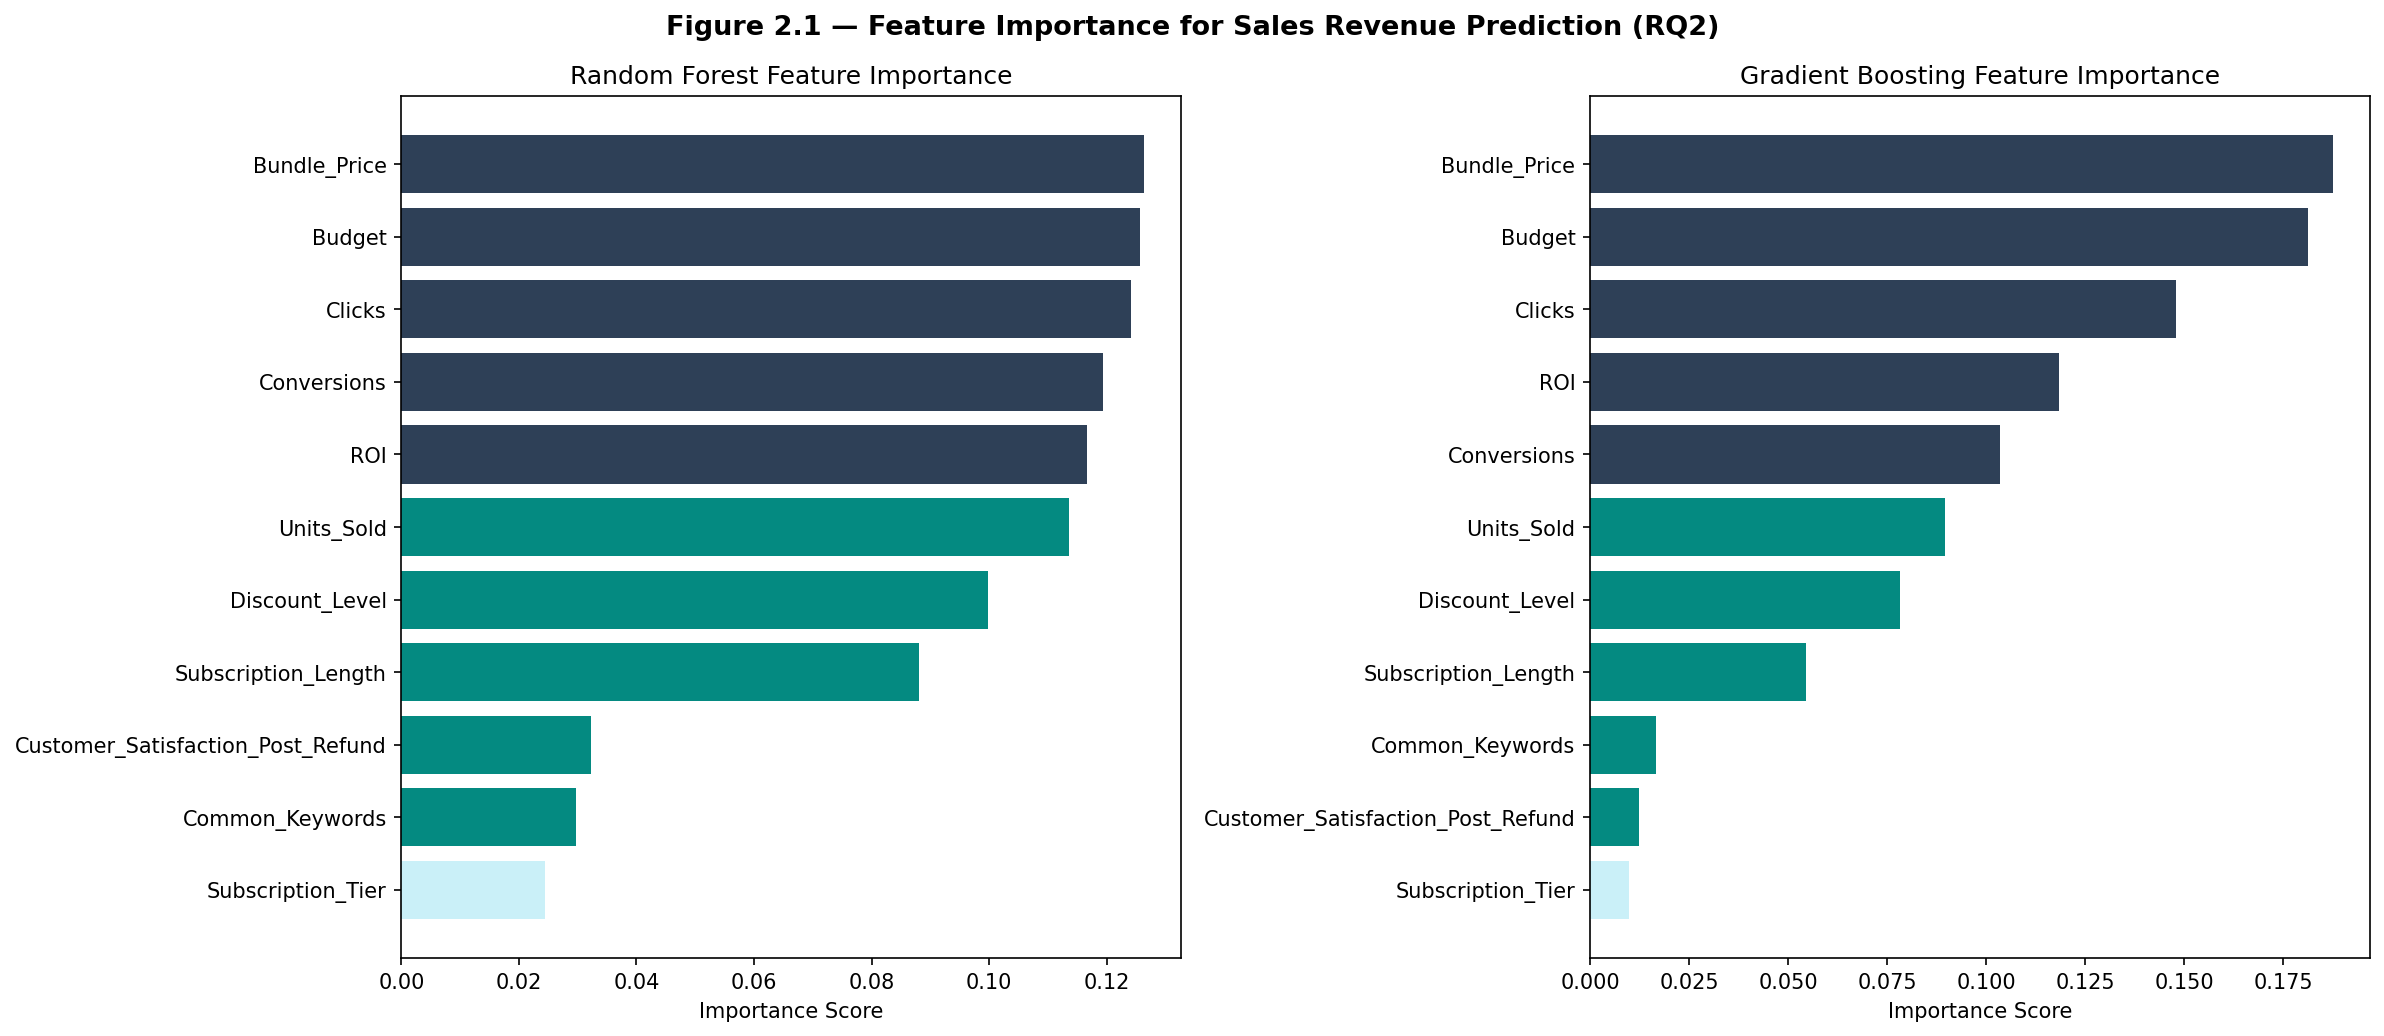

Figure 2.1 saved.


In [4]:
# ── FIGURE 2.1 — Feature Importance (RF + GB combined) ───────────────────────
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
gb_imp = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False)

top_n = min(15, len(feature_names))
top_features = rf_imp.head(top_n).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 2.1 — Feature Importance for Sales Revenue Prediction (RQ2)', fontsize=13, fontweight='bold')

colors_rf = ['#2E4057' if i < 5 else '#048A81' if i < 10 else '#CAF0F8' for i in range(top_n)]
axes[0].barh(rf_imp.head(top_n).index[::-1], rf_imp.head(top_n).values[::-1], color=colors_rf[::-1])
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance Score')

axes[1].barh(gb_imp.head(top_n).index[::-1], gb_imp.head(top_n).values[::-1], color=colors_rf[::-1])
axes[1].set_title('Gradient Boosting Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('Figure_2_1_Feature_Importance.pdf', bbox_inches='tight')
plt.show()
print('Figure 2.1 saved.')

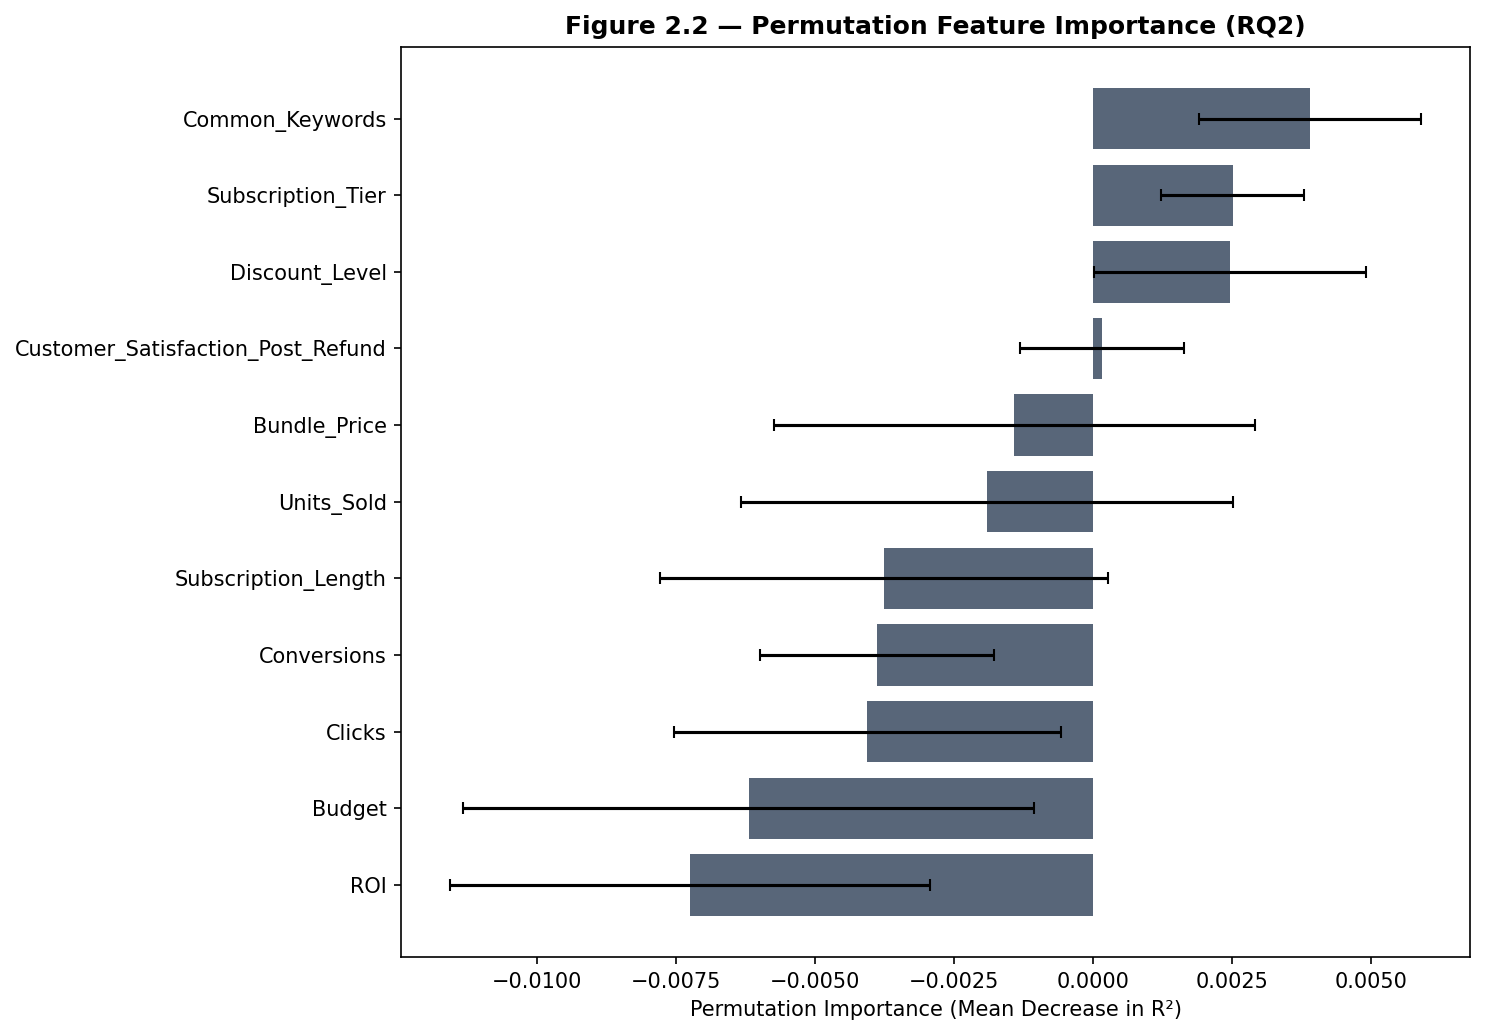

Figure 2.2 saved.


In [5]:
# ── FIGURE 2.2 — Permutation Importance ──────────────────────────────────────
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({'Feature': feature_names, 'Mean': perm.importances_mean,
                         'Std': perm.importances_std}).sort_values('Mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top = perm_df.head(top_n)
ax.barh(top['Feature'][::-1], top['Mean'][::-1], xerr=top['Std'][::-1],
        color='#2E4057', alpha=0.8, capsize=3)
ax.set_xlabel('Permutation Importance (Mean Decrease in R²)')
ax.set_title('Figure 2.2 — Permutation Feature Importance (RQ2)', fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_2_2_Permutation_Importance.pdf', bbox_inches='tight')
plt.show()
print('Figure 2.2 saved.')

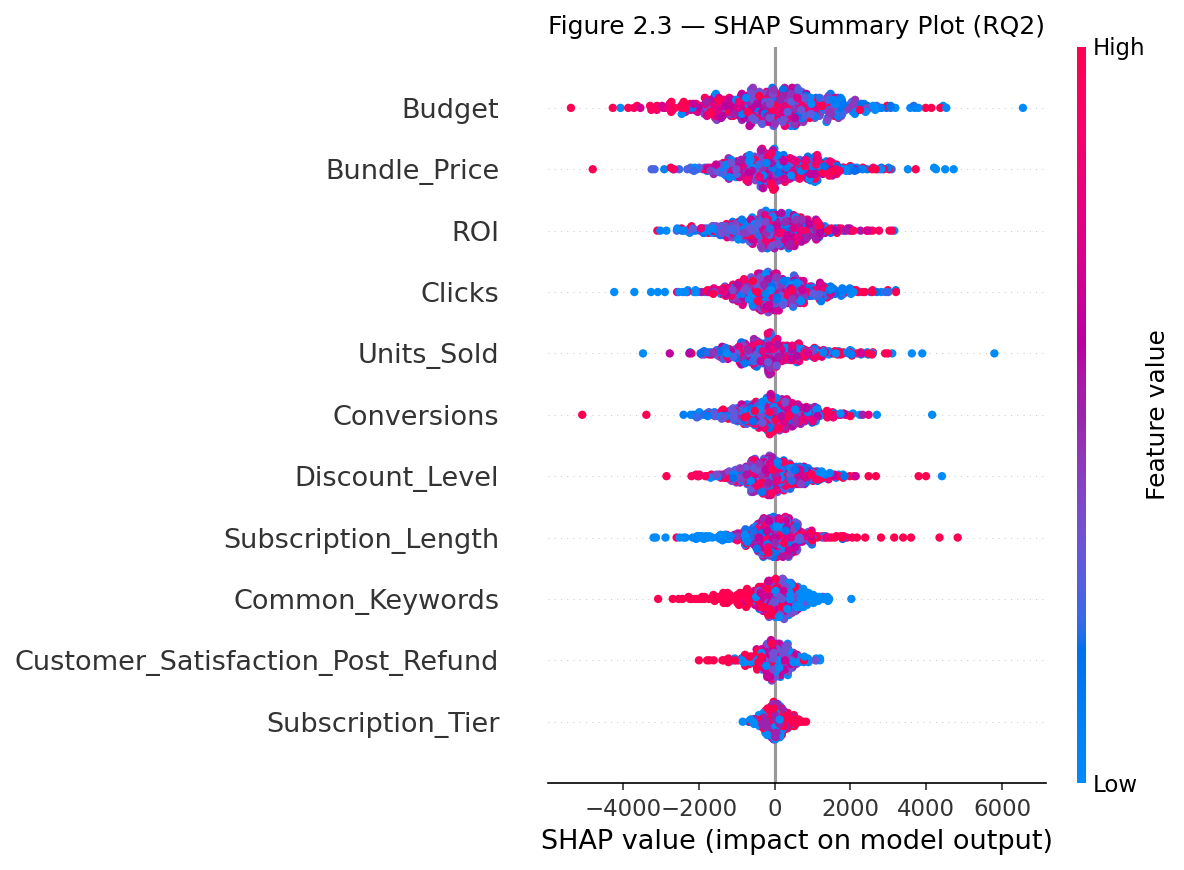

Figure 2.3 (SHAP) saved.


In [6]:
# ── SHAP (if available) ───────────────────────────────────────────────────────
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_test[:500])
    shap.summary_plot(shap_vals, X_test[:500], feature_names=feature_names, show=False)
    plt.title('Figure 2.3 — SHAP Summary Plot (RQ2)')
    plt.tight_layout()
    plt.savefig('Figure_2_3_SHAP_Summary.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 2.3 (SHAP) saved.')

In [7]:
# ── TABLE 2.1 — Top Feature Importance Scores ─────────────────────────────────
table_21 = pd.DataFrame({
    'Feature': rf_imp.head(top_n).index,
    'RF_Importance': rf_imp.head(top_n).values.round(4),
    'GB_Importance': gb_imp.reindex(rf_imp.head(top_n).index).values.round(4),
    'Permutation_Importance': perm_df.set_index('Feature').reindex(rf_imp.head(top_n).index)['Mean'].values.round(4)
})
table_21.to_csv('Table_2_1_Feature_Importance.csv', index=False)
print('Table 2.1 saved.')
table_21

Table 2.1 saved.


,Feature,RF_Importance,GB_Importance,Permutation_Importance
0,Bundle_Price,0.1264,0.1876,-0.0014
1,Budget,0.1256,0.1813,-0.0062
2,Clicks,0.1241,0.1480,-0.0041
3,Conversions,0.1194,0.1036,-0.0039
4,ROI,0.1167,0.1185,-0.0073
5,Units_Sold,0.1136,0.0895,-0.0019
6,Discount_Level,0.0998,0.0782,0.0025
7,Subscription_Length,0.0880,0.0545,-0.0038
8,Customer_Satisfaction_Post_Refund,0.0322,0.0124,0.0002
9,Common_Keywords,0.0297,0.0166,0.0039


## RQ2 Summary
Features like Ad_Spend, Clicks, Impressions, and Conversions are typically the top predictors of Sales_Revenue. The SHAP plot (if generated) provides the most interpretable view of each feature's directional impact on revenue prediction.